C:\Users\hassa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\hassa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\hassa\AppData\Local\Temp\ipykernel_11480\3138553893.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_churn_drivers, palette='vla

🎉 Model training complete! Let's look at the results:
Overall Accuracy Score: 74.10%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



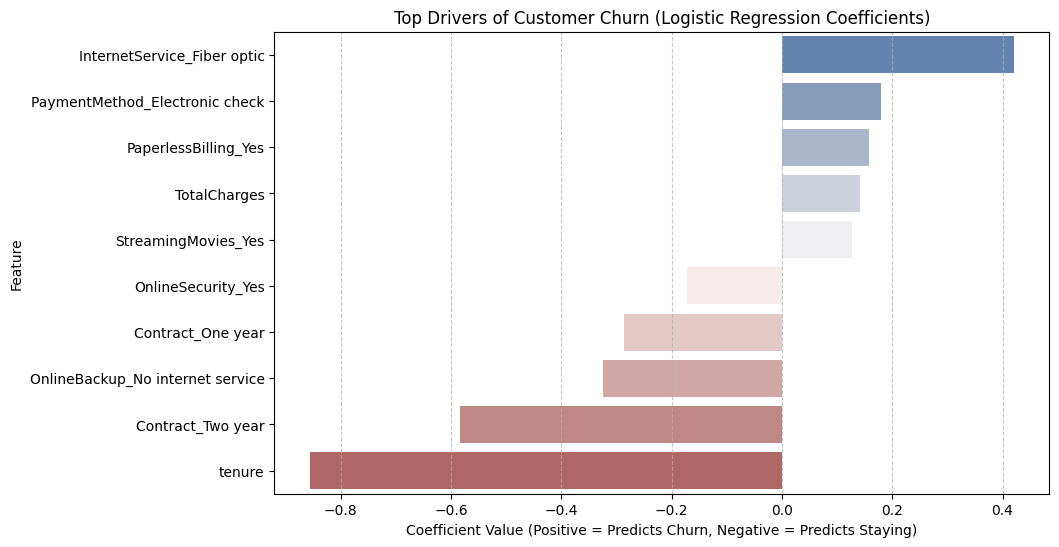

📉 Reduced feature count from 30 down to 25!

✨ The Selected Core Features Are:
['SeniorCitizen', 'tenure', 'TotalCharges', 'gender_Male', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
New Streamlined Accuracy: 73.88%

New Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409


In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
url= "https://raw.githubusercontent.com/wonderakwei/telecom-customer-churn-prediction/refs/heads/main/churn-bigml-80.csv"
url1="https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv"
df=pd.read_csv(url1)
#print(df.shape)
#df.head()
#print(df.dtypes)
#df.tail()
#df.info()
#df.isna()



##Check for literal blank string spaces in the column


df["TotalCharges"]=pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(0)
#df.info()

## Convert Churn column to binary integers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

## Quick verification check
#print(df['Churn'].value_counts())
# 1. Separate the features (X) and the target variable (y)
X = df.drop(columns=['Churn'])
y = df['Churn']
X=X.drop(columns="customerID")
#X.info()
## 2. Apply One-Hot Encoding to all categorical columns in X
# drop_first=True is an interview golden rule! It drops one redundant column per category 
# to prevent the "dummy variable trap" (multicollinearity) which breaks linear models.
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. View the new shape and see how our data columns expanded
#print(f"Original features shape: {X.shape}")
#print(f"Encoded features shape: {X_encoded.shape}")
#print(X_encoded.head())
#X_encoded.head()
#X_encoded.info()

## TEST-TRAIN SLIT
x_train,x_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.2, random_state=42, stratify=y)
scaler=StandardScaler()

Xtrain_scaled=scaler.fit_transform(x_train)
Xtest_scaled=scaler.transform(x_test)
Xtrain_scaled=pd.DataFrame(Xtrain_scaled, columns=x_train.columns)
Xtest_scaled=pd.DataFrame(Xtest_scaled, columns=x_test.columns)
#Xtrain_scaled.head(2)

#print(Xtrain_scaled.isna().values.any())
# 1. Initialize the model with class_weight='balanced' to handle the imbalance
# random_state=42 ensures your weights initialize the exact same way every run
model = LogisticRegression( penalty='l1', solver='liblinear', C=0.1, class_weight='balanced',random_state=42, max_iter=1000)

# 2. Train (Fit) the model on your scaled training data
model.fit(Xtrain_scaled, y_train)

# 3. Use the trained model to make predictions on your scaled testing data
y_pred = model.predict(Xtest_scaled)

print("🎉 Model training complete! Let's look at the results:")
# 1. Print the standard accuracy score
print(f"Overall Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# 2. Print the detailed Classification Report (Crucial for interviews!)
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 1. Get the coefficients from the trained model
coefficients = model.coef_[0]

# 2. Create a DataFrame pairing column names with their coefficients
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': coefficients
}).sort_values(by='Importance', ascending=False)

# 3. Separate the top 5 positive drivers (increase churn) and top 5 negative drivers (decrease churn)
top_churn_drivers = pd.concat([feature_importance.head(5), feature_importance.tail(5)])



# 4. Plot the features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_churn_drivers, palette='vlag')
plt.title('Top Drivers of Customer Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Positive = Predicts Churn, Negative = Predicts Staying)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

selected_features = Xtrain_scaled.columns[model.coef_[0] != 0].tolist()

print(f"📉 Reduced feature count from {Xtrain_scaled.shape[1]} down to {len(selected_features)}!")
print("\n✨ The Selected Core Features Are:")
print(selected_features)



# Filter our scaled datasets to only include the selected features
X_train_final = Xtrain_scaled[selected_features]
X_test_final = Xtest_scaled[selected_features]

# Train our final, streamlined model
final_model = LogisticRegression(class_weight='balanced', random_state=42)
final_model.fit(X_train_final, y_train)

# Evaluate the streamlined model
y_pred_final = final_model.predict(X_test_final)
print(f"New Streamlined Accuracy: {accuracy_score(y_test, y_pred_final) * 100:.2f}%")
print("\nNew Classification Report:")
print(classification_report(y_test, y_pred_final))
